In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plot_scripts as plts
plt.style.use("mplstyle")

In [2]:
dnuc = 40e-3            # MHz
nua = np.load('nua.npy')
N = len(nua)
dnu = np.arange(N)*dnuc

def FGname(inp_signal):
    if (inp_signal == '21cm'):
        FG = 'None'
        dataname = '21cm'
    elif (inp_signal == 'FG+21cm'):
        FG = 'Smooth'
        dataname = 'FG'
    elif (inp_signal == 'FG+MM+21cm'):
        FG = 'Unsmooth'
        dataname = 'FGMM'
    return FG, dataname

cl21 = np.load('cl21.npy')

In [9]:
path = 'results'
inp_signal = 'FG+MM+21cm'
# inp_signal = 'FG+21cm'
# inp_signal = '21cm'
FG, dataname = FGname(inp_signal)
SCF = 'Hann'

# ---------- NO FLAG ----------
mode = 'NOFLAG'
data = np.load(f"{path}/CL_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz")
cl = data["cl"]
Nrea = cl.shape[0]
cla_noflag = np.mean(cl, axis=0)
cle_noflag = np.std(cl, axis=0) / np.sqrt(Nrea)

# ---------- PERIODIC ----------
mode = 'PERIODIC'
data = np.load(f"{path}/CL_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz")
cl = data["cl"]
cla_periodic = np.mean(cl, axis=0)
cle_periodic = np.std(cl, axis=0) / np.sqrt(Nrea)

# ---------- PERIODIC + RANDOM ----------
mode = 'PERIODIC+RANDOM'
data = np.load(f"{path}/CL_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz")
cl = data["cl"]
cla_prandom = np.mean(cl, axis=0)
cle_prandom = np.std(cl, axis=0) / np.sqrt(Nrea)

# ---------- RANDOM ----------
mode = 'RANDOM'
data = np.load(f"{path}/CL_inp_signal-{inp_signal}_flag-{mode}_SCF-{SCF}.npz")
cl = data["cl"]
cla_random = np.mean(cl, axis=0)
cle_random = np.std(cl, axis=0) / np.sqrt(Nrea)



/tmp/ipykernel_4076941/707476302.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_4076941/707476302.py:81: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


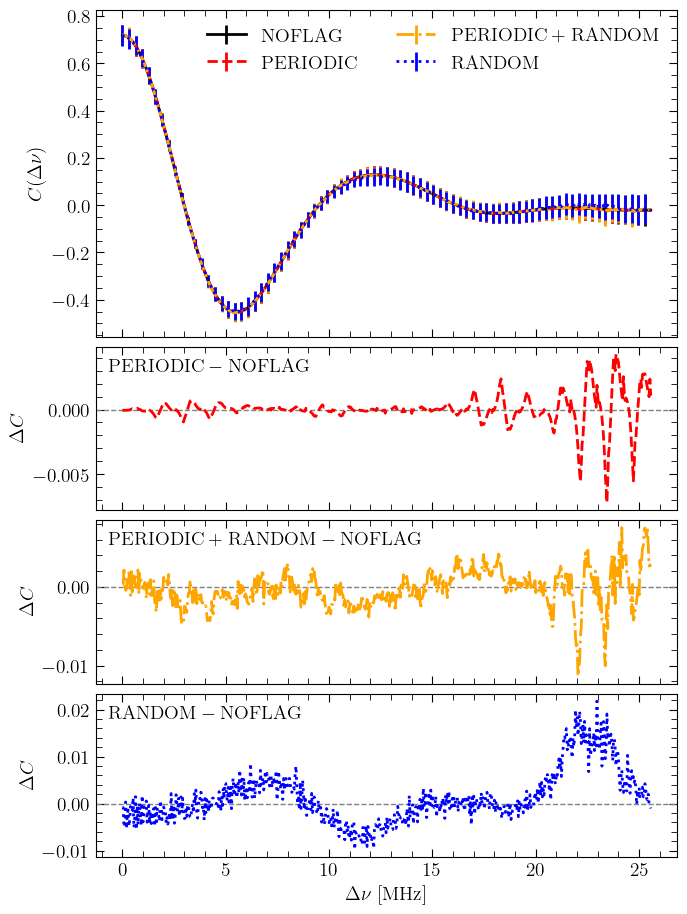

In [10]:
nc1 = 640

fig, axes = plt.subplots(
    4, 1,
    figsize=(7.5, 11),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.5, 1.5, 1.5], "hspace": 0.05}
)

ax0, ax1, ax2, ax3 = axes

# ============================
# Top panel: C(Δν)
# ============================
# ax0.plot(
#     dnu[:nc1], cl21[:nc1]/cl21[0], label=r'$\rm{EoR}$'
# )

ax0.errorbar(
    dnu[:nc1], cla_noflag[:nc1], cle_noflag[:nc1],
    color='k', lw=2, ls='-', errorevery=8,
    label=r'$\rm{NOFLAG}$'
)
ax0.errorbar(
    dnu[:nc1], cla_periodic[:nc1], cle_periodic[:nc1],
    color='r', lw=2, ls='--', errorevery=8,
    label=r'$\rm{PERIODIC}$'
)
ax0.errorbar(
    dnu[:nc1], cla_prandom[:nc1], cle_prandom[:nc1],
    color='orange', lw=2, ls='-.',errorevery=8,
    label=r'$\rm{PERIODIC+RANDOM}$'
)
ax0.errorbar(
    dnu[:nc1], cla_random[:nc1], cle_random[:nc1],
    color='b', lw=2, ls=':',errorevery=8,
    label=r'$\rm{RANDOM}$'
)

ax0.set_ylabel(r'$C(\Delta\nu)$')
ax0.legend(frameon=False, ncol=2)
# ax0.grid(alpha=0.3)

# ============================
# PERIODIC − NOFLAG
# ============================
diff = cla_periodic[:nc1] - cla_noflag[:nc1]

ax1.axhline(0, color='gray', ls='--', lw=1)
ax1.plot(dnu[:nc1], diff, color='r', lw=2, ls='--')

ax1.set_ylabel(r'$\Delta C$')
ax1.text(0.02, 0.85, r'$\rm{PERIODIC - NOFLAG}$', transform=ax1.transAxes)
# ax1.grid(alpha=0.3)

# ============================
# PERIODIC+RANDOM − NOFLAG
# ============================
diff = cla_prandom[:nc1] - cla_noflag[:nc1]

ax2.axhline(0, color='gray', ls='--', lw=1)
ax2.plot(dnu[:nc1], diff, color='orange', lw=2, ls='-.')

ax2.set_ylabel(r'$\Delta C$')
ax2.text(0.02, 0.85, r'$\rm{PERIODIC+RANDOM - NOFLAG}$', transform=ax2.transAxes)
# ax2.grid(alpha=0.3)

# ============================
# RANDOM − NOFLAG
# ============================
diff = cla_random[:nc1] - cla_noflag[:nc1]

ax3.axhline(0, color='gray', ls='--', lw=1)
ax3.plot(dnu[:nc1], diff, color='b', lw=2, ls=':')

ax3.set_ylabel(r'$\Delta C$')
ax3.set_xlabel(r'$\Delta\nu\ {\rm [MHz]}$')
ax3.text(0.02, 0.85, r'$\rm{RANDOM - NOFLAG}$', transform=ax3.transAxes)
# ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
%%%%%%%%%%%55

/tmp/ipykernel_3893386/3830009597.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


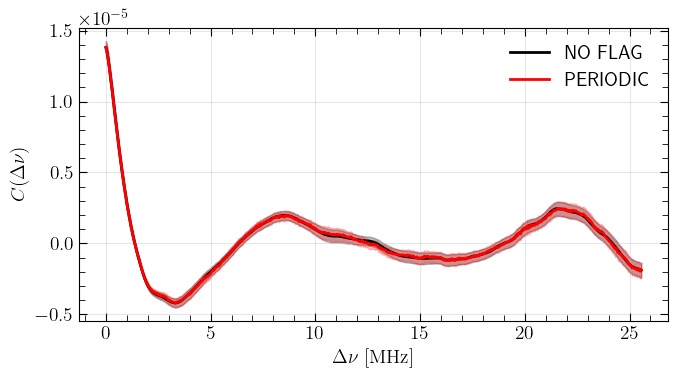

/tmp/ipykernel_3893386/3830009597.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


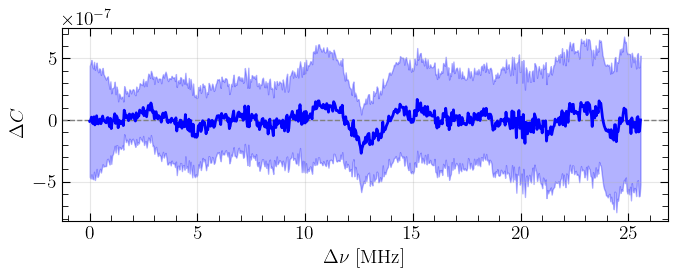

In [54]:
plt.figure(figsize=(7, 4))

plt.plot(dnu[:nc1], cla_noflag[:nc1], color='k', lw=2, label='NO FLAG')
plt.fill_between(
    dnu[:nc1],
    cla_noflag[:nc1] - cle_noflag[:nc1],
    cla_noflag[:nc1] + cle_noflag[:nc1],
    color='k', alpha=0.25
)

plt.plot(dnu[:nc1], cla_periodic[:nc1], color='r', lw=2, label='PERIODIC')
plt.fill_between(
    dnu[:nc1],
    cla_periodic[:nc1] - cle_periodic[:nc1],
    cla_periodic[:nc1] + cle_periodic[:nc1],
    color='r', alpha=0.25
)

plt.xlabel(r'$\Delta\nu\ {\rm [MHz]}$')
plt.ylabel(r'$C(\Delta\nu)$')
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cl_diff  = cla_periodic[:nc1] - cla_noflag[:nc1]
cle_diff = np.sqrt(cle_periodic[:nc1]**2 + 0*cle_noflag[:nc1]**2)

plt.figure(figsize=(7, 3))

plt.axhline(0.0, color='gray', ls='--', lw=1)
plt.plot(dnu[:nc1], cl_diff[:nc1], color='b', lw=2)
plt.fill_between(
    dnu[:nc1],
    cl_diff[:nc1] - cle_diff[:nc1],
    cl_diff[:nc1] + cle_diff[:nc1],
    color='b', alpha=0.3
)

plt.xlabel(r'$\Delta\nu\ {\rm [MHz]}$')
plt.ylabel(r'$\Delta C$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [41]:
cla_noflag.shape, 
nc1 = 640 # len(cla_periodic)

In [42]:
cla_noflag.shape, cla_periodic.shape

((768,), (760,))

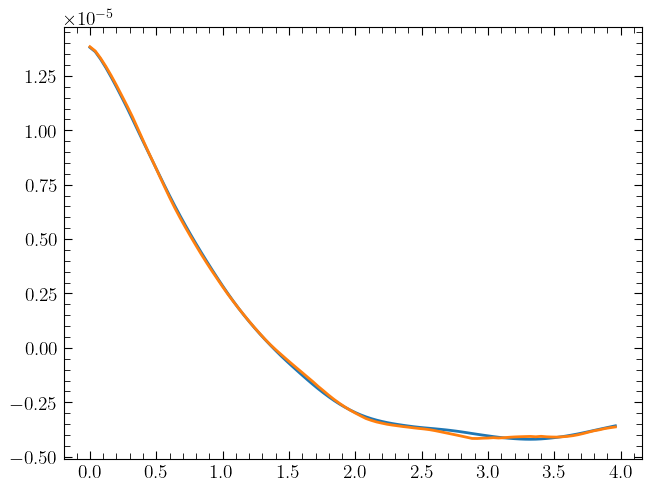

In [43]:
nnm = 100
plt.plot(dnu[:nnm], cla_noflag[:nnm])
plt.plot(dnu[:nnm], cla_periodic[:nnm])



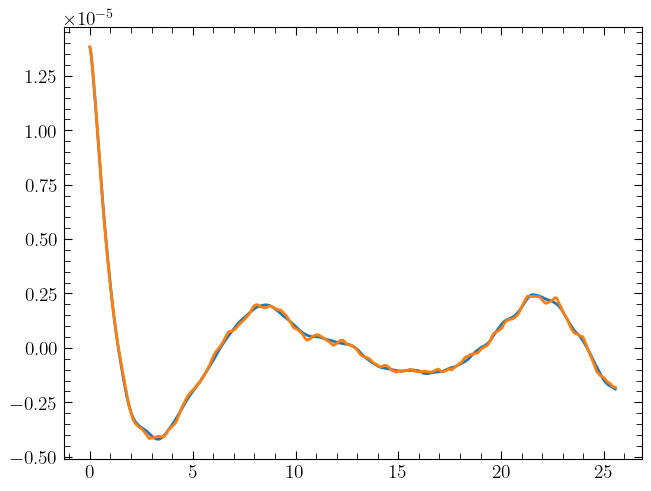

In [44]:
plt.plot(dnu[:nc1], cla_noflag[:nc1])
plt.plot(dnu[:nc1], cla_periodic[:nc1])
plt.show()


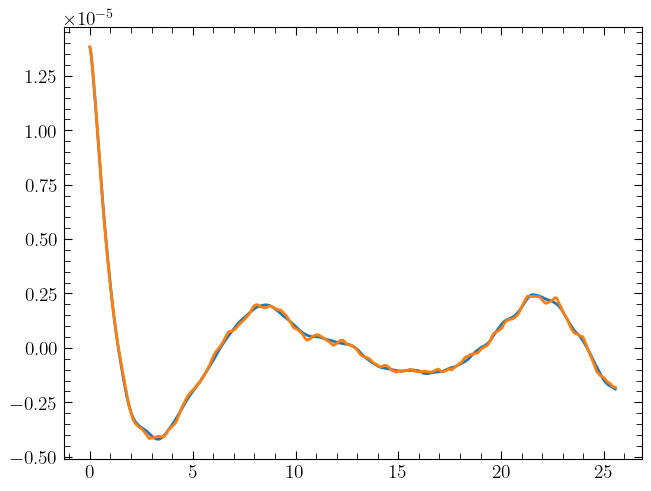

In [45]:
plt.plot(dnu[:nc1], cla_noflag[:nc1])
plt.plot(dnu[:nc1], cla_periodic[:nc1])
# plt.plot(dnu[:nc1], cla_periodic)
plt.show()


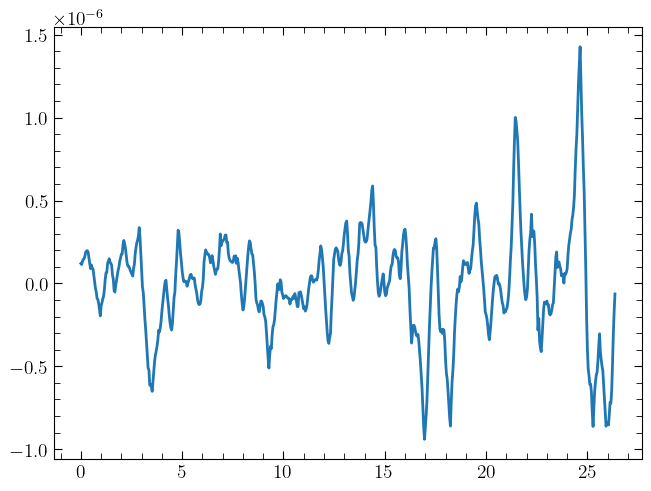

In [21]:
plt.plot(dnu[:nc1], cla_noflag[:nc1]-cla_periodic[:nc1])


In [10]:
%%

UsageError: Cell magic `%%` not found.
